In [5]:
# -*- coding: utf-8 -*-
# No NoiseScheduleVP — purely from Diffusers DiTPipeline.
# Classes: CTScheduler (CFG + coeffs), EulerSolver (DDIM η=0), DPMSolver (DPM++ 2M, data-pred)
# Then: sample 10 images with 10 steps for each, display as PIL grids (notebook-friendly).

import numpy as np
import torch
from diffusers import DiTPipeline
from PIL import Image
from IPython.display import display

# ==================== CTScheduler ====================
class CTScheduler:
    """
    Build continuous-time coeffs and CFG preds directly from `pipe.scheduler.betas`.
    - τ grid: 1 → 0 (length = steps+1)
    - α_i, σ_i via geometric interpolation of ᾱ(k) = ∏(1-β_k)
    - t_int[i] = floor(τ_i * N) for model calls
    - eps_i(x,i): CFG ε̂ at node i  (learned_sigma=True handled by slicing)
    - x0_i(x,i) : x̂0 at node i
    """
    def __init__(self, pipe, labels, steps=10, cfg=4.0, null_id=1000, dtype=torch.float16):
        self.pipe   = pipe
        self.labels = labels
        self.null   = torch.full_like(labels, null_id)
        self.cfg    = float(cfg)
        self.dtype  = dtype
        self.C      = int(pipe.transformer.config.in_channels)  # ε-channels (learned_sigma-aware)

        # betas → log ᾱ(k), k=0..N  (loga[0]=0)
        betas = pipe.scheduler.betas if isinstance(pipe.scheduler.betas, torch.Tensor) \
                else torch.as_tensor(pipe.scheduler.config.trained_betas)
        b = betas.detach().cpu().numpy().reshape(-1)
        self.N = int(b.size)
        loga = np.zeros(self.N + 1, dtype=np.float64)
        loga[1:] = np.cumsum(np.log(1.0 - b + 1e-12))
        self.loga = torch.as_tensor(loga, device=labels.device, dtype=torch.float64)

        # τ grid (steps+1 nodes) → α_i, σ_i, t_int[i]
        self.S  = int(steps) + 1
        tau = torch.linspace(1.0, 0.0, self.S, device=labels.device, dtype=torch.float64)  # [S]
        u   = tau * self.N
        k   = torch.floor(u).long().clamp(0, self.N - 1)   # [S]
        f   = (u - k.to(torch.float64))                    # [S]
        logabar = (1. - f) * self.loga[k] + f * self.loga[k + 1]
        a = torch.sqrt(torch.exp(logabar)).to(self.dtype)                    # α_i
        s = torch.sqrt(torch.clamp(1. - a * a, min=0.0)).to(self.dtype)      # σ_i

        self.alphas = a   # [S]
        self.sigmas = s   # [S]
        self.t_int  = k   # [S] (for model)

    @torch.no_grad()
    def eps_i(self, x: torch.Tensor, i: int) -> torch.Tensor:
        tvec = self.t_int[i].expand(x.size(0))  # [B] long
        tr = self.pipe.transformer
        out_c = tr(hidden_states=x, timestep=tvec, class_labels=self.labels.to(x.device), return_dict=True).sample
        out_u = tr(hidden_states=x, timestep=tvec, class_labels=self.null.to(x.device),   return_dict=True).sample
        return (out_u[:, :self.C] + self.cfg * (out_c[:, :self.C] - out_u[:, :self.C])).to(x.dtype)

    @torch.no_grad()
    def x0_i(self, x: torch.Tensor, i: int) -> torch.Tensor:
        eps = self.eps_i(x, i)
        ai  = self.alphas[i].view(1, *([1]*(x.ndim-1)))
        si  = self.sigmas[i].view(1, *([1]*(x.ndim-1)))
        return (x - si * eps) / (ai + 1e-12)


# ==================== EulerSolver (DDIM η=0) ====================
class EulerSolver:
    """x0=(x−σ ε)/α ;  x' = α' x0 + σ' ε."""
    def __init__(self, eps: float = 1e-12):
        self.eps = float(eps)

    @torch.no_grad()
    def sample(self, scheduler: CTScheduler, latents: torch.Tensor, mode: str = "noise") -> torch.Tensor:
        x = latents
        a, s = scheduler.alphas, scheduler.sigmas
        print(a)
        print(s)
        for i in range(scheduler.S - 1):
            ai = a[i].view(1, *([1]*(x.ndim-1))); si = s[i].view(1, *([1]*(x.ndim-1)))
            if mode == "noise":
                eps = scheduler.eps_i(x, i)
                x0  = (x - si * eps) / (ai + self.eps)
            else:  # "data"
                x0  = scheduler.x0_i(x, i)
                eps = (x - ai * x0) / (si + self.eps)
            aj = a[i+1].view(1, *([1]*(x.ndim-1))); sj = s[i+1].view(1, *([1]*(x.ndim-1)))
            x  = aj * x0 + sj * eps
        return x


# ==================== DPMSolver (DPM++ 2M, data-pred only) ====================
# Drop-in replacement for the previous DPMSolver (DPM++ 2M, data-pred only)
# Adds: final_lower_order — use a 1st-order (Euler) fallback on the LAST step for stability.

import torch

class DPMSolver:
    """
    DPM-Solver++ 2M (data prediction only)
      - step 0: Euler
      - steps 1..: 2M (AB2) with x̂0 differences
      - FINAL STEP (k = S-2): if final_lower_order=True, use Euler (order-1) fallback
    Requires: CTScheduler (provides alphas/sigmas/x0_i).
    """
    def __init__(self, eps: float = 1e-12):
        self.eps = float(eps)

    @torch.no_grad()
    def sample(self, scheduler, latents: torch.Tensor, final_lower_order: bool = True) -> torch.Tensor:
        x = latents
        a, s, S = scheduler.alphas, scheduler.sigmas, scheduler.S
        # λ_i from α,σ (for φ1(-h))
        lam = (a.clamp_min(1e-12).log() - s.clamp_min(1e-12).log()).to(torch.float32)  # [S]
        
        # --- step 0: Euler ---
        h = lam[1] - lam[0]
        phi1 = torch.expm1(-h).to(x.dtype)
        x0_s = scheduler.x0_i(x, 0)
        x    = (s[1] / s[0]) * x - a[1] * phi1 * x0_s

        # cache last two x̂0
        x0_prev1 = x0_s
        x0_prev0 = scheduler.x0_i(x, 1)

        if S <= 2:
            return x  # nothing else to do

        # --- steps 1..S-2 ---
        for k in range(1, S - 1):
            h0 = lam[k]   - lam[k-1]
            h  = lam[k+1] - lam[k]
            phi1 = torch.expm1(-h).to(x.dtype)

            is_final = (k == S - 2)
            if final_lower_order and is_final:
                # order-1 fallback (Euler) on the last step:
                # x_{k+1} = (σ_{k+1}/σ_k) x_k − α_{k+1} φ1(-h) · x̂0_k
                x = (s[k+1] / s[k]) * x - a[k+1] * phi1 * x0_prev0
            else:
                # 2M (AB2) update:
                r0 = h0 / (h + self.eps)
                D1 = (x0_prev0 - x0_prev1) / (r0 + self.eps)
                x  = (s[k+1] / s[k]) * x - a[k+1] * phi1 * (x0_prev0 + 0.5 * D1)

            if not is_final:
                # advance x̂0 window for next step
                x0_prev1, x0_prev0 = x0_prev0, scheduler.x0_i(x, k+1)

        return x

# ==================== helpers (PIL display) ====================
@torch.no_grad()
def latents_to_pils(pipe, latents):
    imgs = pipe.vae.decode(latents / pipe.vae.config.scaling_factor).sample  # [-1,1], [B,3,H,W]
    imgs = ((imgs.clamp(-1, 1) + 1) * 127.5).to(torch.uint8).permute(0,2,3,1).cpu().numpy()
    return [Image.fromarray(a, mode="RGB") for a in imgs]

def pil_grid(pils, ncols=5, pad=4, bg=(240,240,240)):
    w, h = pils[0].size
    nrows = (len(pils) + ncols - 1) // ncols
    grid = Image.new("RGB", (ncols*w + (ncols+1)*pad, nrows*h + (nrows+1)*pad), bg)
    k = 0
    for r in range(nrows):
        for c in range(ncols):
            if k >= len(pils): break
            grid.paste(pils[k], (pad + c*(w+pad), pad + r*(h+pad)))
            k += 1
    return grid




Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]An error occurred while trying to fetch /home/scpark/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a632f08807fbaab0b704d0/transformer: Error no file named diffusion_pytorch_model.safetensors found in directory /home/scpark/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a632f08807fbaab0b704d0/transformer.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  33%|███▎      | 1/3 [00:00<00:00,  8.85it/s]An error occurred while trying to fetch /home/scpark/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a632f08807fbaab0b704d0/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/scpark/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a632f08807fbaab0b704d0/vae.
Defaulting to unsafe serial

tensor([0.0064, 0.0166, 0.0391, 0.0835, 0.1609, 0.2803, 0.4418, 0.6296, 0.8118,
        0.9471, 1.0000], device='cuda:0')
tensor([1.0000, 0.9999, 0.9992, 0.9965, 0.9870, 0.9599, 0.8971, 0.7769, 0.5839,
        0.3209, 0.0000], device='cuda:0')


/tmp/ipykernel_16530/1532788879.py:159: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return [Image.fromarray(a, mode="RGB") for a in imgs]


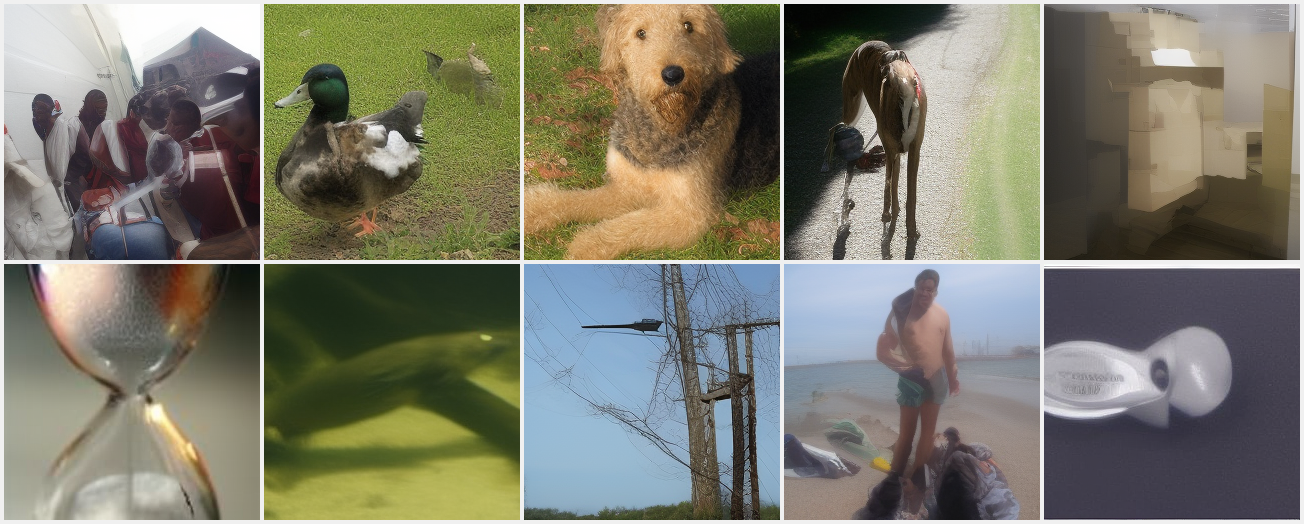

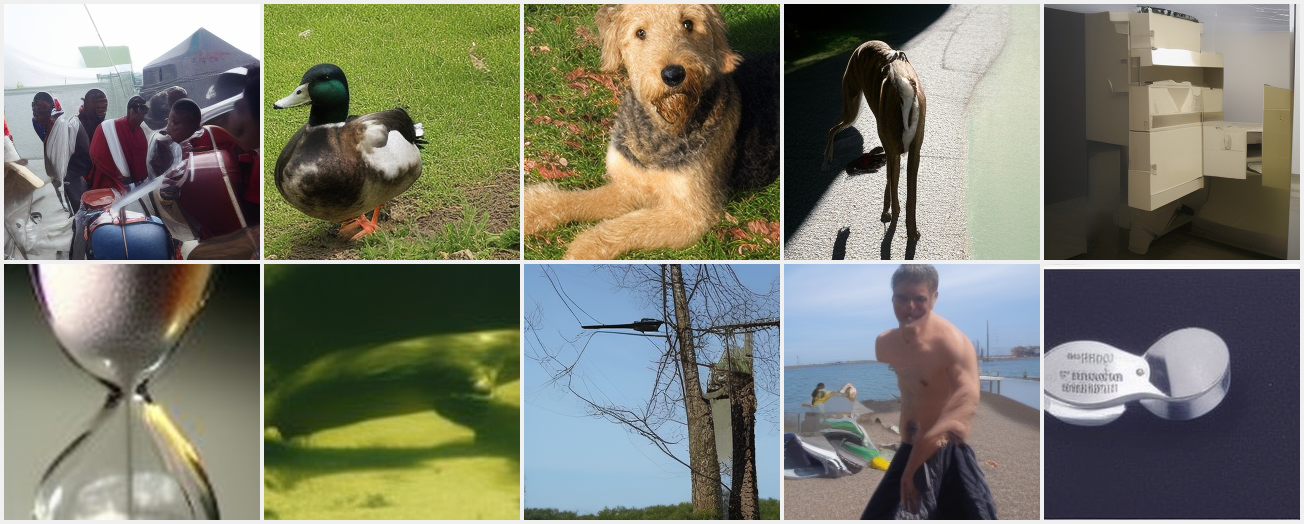

In [6]:
# ==================== run & display (notebook) ====================
# Device / dtype
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32  # CPU fallback

# Seed 고정 (CPU, CUDA, 연산결정성)
seed = 0
torch.manual_seed(seed)
if device.type == "cuda":
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Load model
pipe = DiTPipeline.from_pretrained("facebook/DiT-XL-2-256", torch_dtype=dtype).to(device)
pipe.vae.enable_slicing()

# Config
B, steps, cfg_scale = 10, 10, 1.5
labels = torch.randint(0, 1000, (B,), device=device)

# Euler (noise-pred mode)
sched_e = CTScheduler(pipe, labels, steps=steps, cfg=cfg_scale, null_id=1000, dtype=dtype)
euler = EulerSolver()
noises = torch.randn(B, 4, 32, 32, device=device, dtype=dtype)
lat_e = euler.sample(scheduler=sched_e, latents=noises, mode="noise")
grid_e = pil_grid(latents_to_pils(pipe, lat_e), ncols=5)
display(grid_e)

# DPM-Solver++ 2M (data-pred)
sched_d = CTScheduler(pipe, labels, steps=steps, cfg=cfg_scale, null_id=1000, dtype=dtype)
dpm = DPMSolver()
lat_d = dpm.sample(scheduler=sched_d, latents=noises)
grid_d = pil_grid(latents_to_pils(pipe, lat_d), ncols=5)
display(grid_d)


In [7]:
torch.save({'dpm' : lat_e.float().detach().cpu()}, f='../dpm1.pt')

In [8]:
lat_d

tensor([[[[ 1.7862e+00,  1.4749e+00,  1.5748e+00,  ...,  1.9267e+00,
            1.6248e+00,  1.7502e+00],
          [ 1.5924e+00,  1.3087e+00,  1.5961e+00,  ...,  1.6649e+00,
            1.5228e+00,  1.6339e+00],
          [ 1.8118e+00,  1.4942e+00,  1.5549e+00,  ...,  1.6611e+00,
            1.5198e+00,  1.5733e+00],
          ...,
          [-2.4696e-01,  1.1099e-01,  4.3545e-02,  ...,  3.4528e-01,
           -2.0553e-01,  6.3936e-01],
          [ 1.9745e-01,  2.1729e-01, -1.6603e-01,  ..., -5.8244e-01,
           -1.5729e-01, -9.7746e-01],
          [-1.1614e+00,  7.4411e-01,  7.9845e-01,  ..., -1.1812e+00,
           -2.9389e-01,  6.2911e-01]],

         [[ 1.5801e+00,  1.2863e+00,  1.2037e+00,  ...,  1.7437e+00,
            1.4749e+00,  1.5675e+00],
          [ 1.5109e+00,  1.2752e+00,  1.1787e+00,  ...,  1.5855e+00,
            1.4534e+00,  1.8066e+00],
          [ 1.3363e+00,  1.1804e+00,  1.1714e+00,  ...,  1.3376e+00,
            1.3215e+00,  1.6999e+00],
          ...,
     